In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score 

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

In [3]:
heart_df = pd.read_csv("heart_disease_data.csv")

In [4]:
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [5]:
heart_df.describe()
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


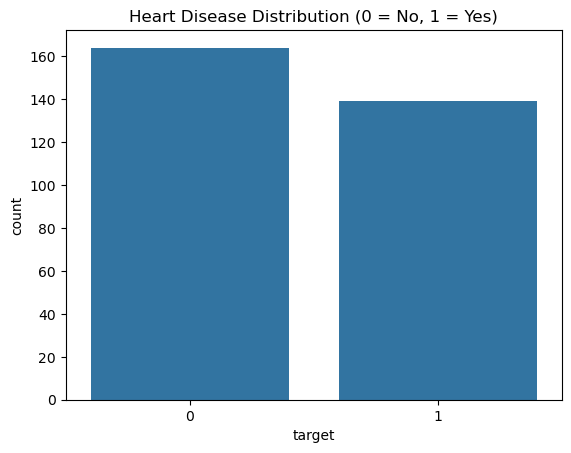

In [6]:


sns.countplot(x='target', data=heart_df)
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

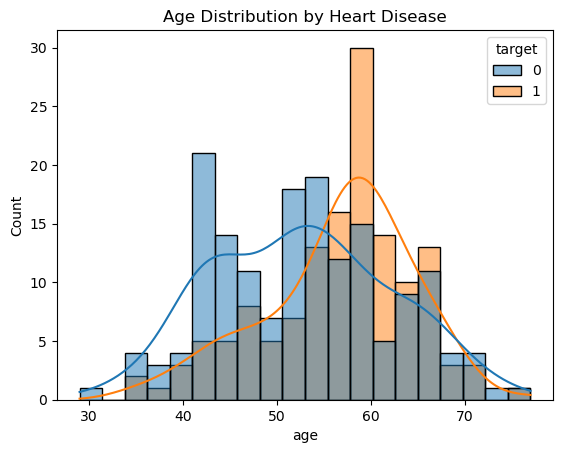

In [7]:
sns.histplot(data=heart_df, x='age', hue='target', bins=20, kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

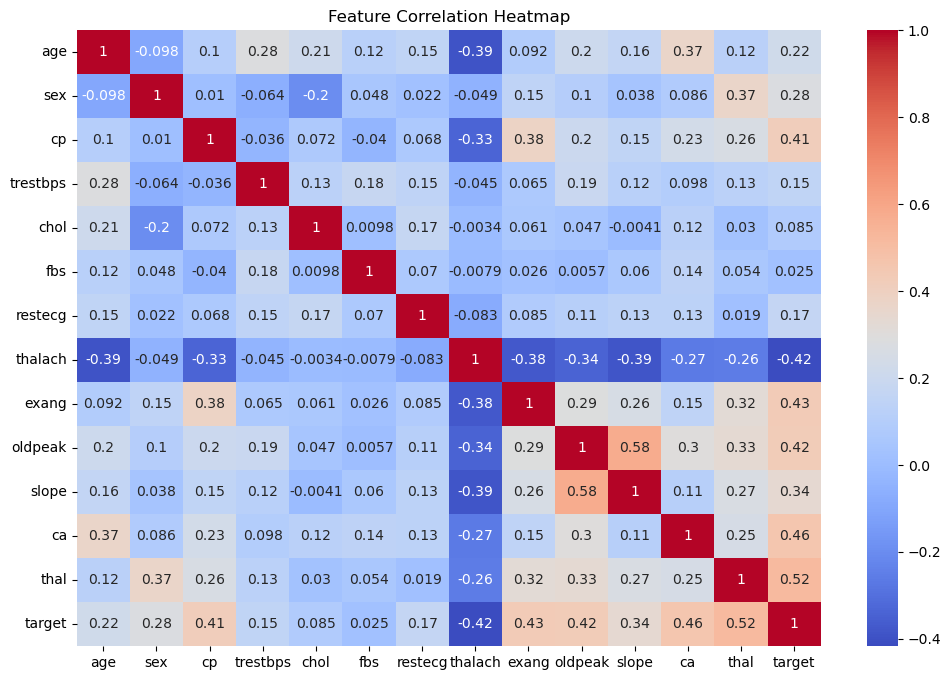

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

<Figure size 640x480 with 0 Axes>

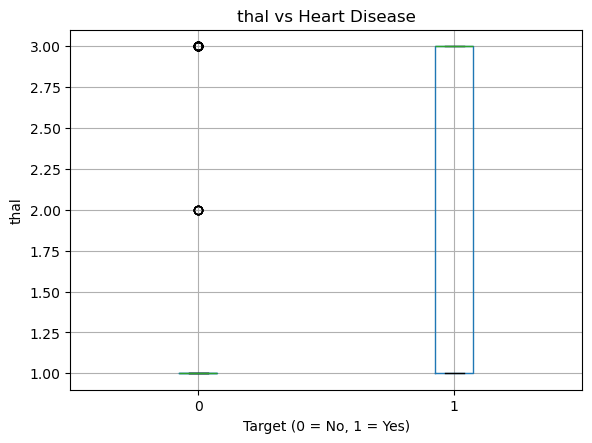

<Figure size 640x480 with 0 Axes>

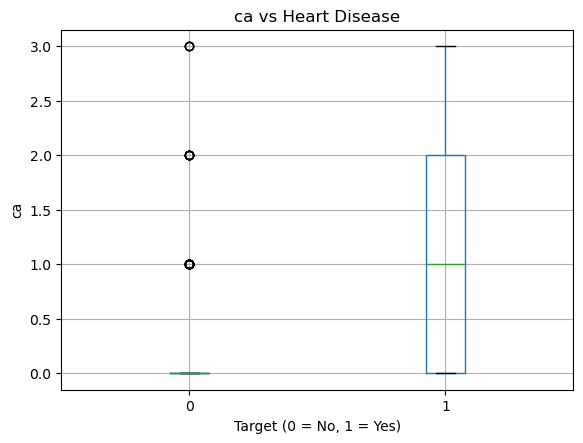

<Figure size 640x480 with 0 Axes>

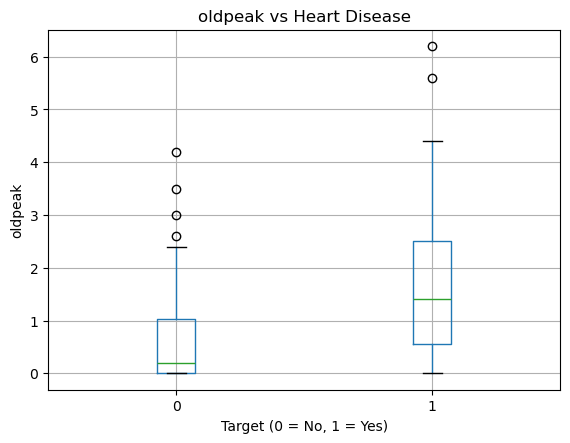

In [9]:
# Top 3 features
features = ['thal', 'ca', 'oldpeak']

for feature in features:
    plt.figure()
    heart_df.boxplot(column=feature, by='target')
    plt.title(f"{feature} vs Heart Disease")
    plt.suptitle("")  # remove extra title
    plt.xlabel("Target (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.show()

In [10]:
# train test split 

selected_features = ['thalach', 'cp', 'ca', 'thal', 'oldpeak', 'age', 'chol', 'trestbps']

X = heart_df[selected_features]
y = heart_df["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=42,stratify=y   
)

In [11]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(242, 8) (61, 8)
target
0    131
1    111
Name: count, dtype: int64
target
0    33
1    28
Name: count, dtype: int64


In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = model.predict(X_test)


In [17]:

# Accuracy score check karein
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

# Confusion Matrix (Isse pata chalega ki kitne cases sahi pakde aur kitne galat)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 88.52%

Confusion Matrix:
[[29  4]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



In [19]:
import pickle
import os

# 1. Pehle folder banate hain agar wo nahi exist karta
folder_name = 'Heart_disease_data'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' ban gaya hai.")

# 2. Ab model save karte hain
# 'heart_model.pkl' naam se save kar rahe hain
file_path = os.path.join(folder_name, 'heart_model.pkl')

with open(file_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model successfully save ho gaya hai yahan: {file_path}")

Folder 'Heart_disease_data' ban gaya hai.
Model successfully save ho gaya hai yahan: Heart_disease_data\heart_model.pkl
